This is the basic code. We cannot use classification_report as per the guidelines and have to decide a metric to base our performances on. We have to make ten variants of this algorithm. Lets add all the variants in different blocks of this notebook as it would simplify compilation of all the code in the future.

       Chamber_Temperature  Gas_Flow_Rate     RF_Power   Etch_Depth  \
count          4219.000000    4219.000000  4219.000000  4219.000000   
mean             75.077152      49.936138   301.363854   498.669397   
std               5.001785      10.118648    49.478589   101.450988   
min              55.718123       5.343961   127.597854   157.862038   
25%              71.709006      42.950962   267.563073   430.825513   
50%              75.088763      49.944598   301.023759   500.385843   
75%              78.468876      57.010941   335.050447   566.789573   
max              97.395421      86.024150   476.826583   874.537923   

       Rotation_Speed  Vacuum_Pressure  Stage_Alignment_Error  \
count     4219.000000      4219.000000            4219.000000   
mean      1504.745316         0.500660               2.002765   
std        202.833239         0.049935               0.817832   
min        859.588352         0.346181              -1.570375   
25%       1368.015130         0.467

/var/folders/t5/627dv0pd3j75b82255bt57n40000gn/T/ipykernel_7768/4186147856.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.23327156  0.26641739 -0.41491338 ...  0.73078808  0.74981966
  0.11797102]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.loc[:,numerical_cols] = scaler.transform(x_train[numerical_cols])
/var/folders/t5/627dv0pd3j75b82255bt57n40000gn/T/ipykernel_7768/4186147856.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-5.86197648e-01  1.55295257e+00 -1.49971376e+00  1.51488940e+00
  3.08286875e-01  8.71621809e-01  6.58468050e-01 -1.12669468e+00
 -9.17347237e-01  2.28354216e-01  1.09238820e+00  1.27509142e+00
  7.95495466e-01 -1.78921716e-01  1.16090191e+00  1.06955030e+00
 -6.69936625e-01  1.03909976e+00 -1.37791161e+00  9.66779737e-01
 -1.46545690e+00 -5.06264988e-01

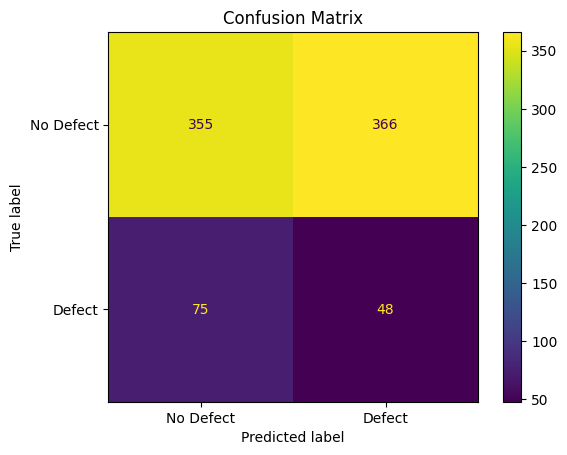

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/aryankulkarni/Documents/UC Berkeley Coursework/SDSE/La_Finale/Semiconductor Quality Control/semiconductor_quality_control.csv')
print(df.describe())
print(df.head())
y = df['Defect']
sybau = ['Process_ID', 'Timestamp', 'Wafer_ID', 'Defect', 'Join_Status']
x = df.drop(columns=sybau)
x = pd.get_dummies(x, columns=['Tool_Type'], drop_first=False)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y)
numerical_cols = ['Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power', 'Etch_Depth',
                  'Rotation_Speed', 'Vacuum_Pressure', 'Stage_Alignment_Error',
                  'Vibration_Level', 'UV_Exposure_Intensity', 'Particle_Count']
scaler = StandardScaler()
scaler.fit(x_train[numerical_cols])
x_train.loc[:,numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test.loc[:,numerical_cols] = scaler.transform(x_test[numerical_cols])
print('Pre-processing done lesogogogogoogogogogogo')
model = LogisticRegression(class_weight='balanced')
model.fit(x_train, y_train)
print('Done!')
y_pred = model.predict(x_test)
print('Yezzur!')
print(classification_report(y_test, y_pred))            
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, display_labels=['No Defect', 'Defect'])
plt.title('Confusion Matrix')
plt.show()      